In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data" / "Data"

print(f"Using device: {device}")
print(f"Dataset folder exists: {DATA_DIR.exists()}")

Using device: cpu
Dataset folder exists: True


In [3]:
scan_records = []

for class_name, label in [("Hemorrhagic", 1), ("NORMAL", 0)]:
    class_dir = DATA_DIR / class_name

    for folder in class_dir.rglob("*"):
        if folder.is_dir() and any(folder.glob("*.jpg")):
            scan_records.append(
                {
                    "scan_id": str(folder.relative_to(DATA_DIR)),
                    "class_name": class_name,
                    "label": label,
                    "slice_count": len(list(folder.glob("*.jpg"))),
                }
            )

scans_df = pd.DataFrame(scan_records)

print(f"Total scans found: {len(scans_df)}")
scans_df["class_name"].value_counts()

Total scans found: 45


class_name
NORMAL         27
Hemorrhagic    18
Name: count, dtype: int64

In [4]:
excluded_scan_id = r"NORMAL\N27[N27]"

scans_df_clean = (
    scans_df[scans_df["scan_id"] != excluded_scan_id]
    .copy()
    .reset_index(drop=True)
)

print(f"Scans used for DenseNet: {len(scans_df_clean)}")
scans_df_clean["class_name"].value_counts()

Scans used for DenseNet: 44


class_name
NORMAL         26
Hemorrhagic    18
Name: count, dtype: int64

In [5]:
train_val_scans, test_scans = train_test_split(
    scans_df_clean,
    test_size=0.20,
    stratify=scans_df_clean["label"],
    random_state=SEED,
)

train_scans, val_scans = train_test_split(
    train_val_scans,
    test_size=0.1875,
    stratify=train_val_scans["label"],
    random_state=SEED,
)

In [6]:
def build_image_dataframe(scan_dataframe):
    records = []

    for _, scan in scan_dataframe.iterrows():
        scan_folder = DATA_DIR / scan["scan_id"]

        for image_path in scan_folder.glob("*.jpg"):
            records.append(
                {
                    "image_path": image_path,
                    "scan_id": scan["scan_id"],
                    "class_name": scan["class_name"],
                    "label": scan["label"],
                }
            )

    return pd.DataFrame(records)


train_images = build_image_dataframe(train_scans)
val_images = build_image_dataframe(val_scans)
test_images = build_image_dataframe(test_scans)

print(len(train_images), len(val_images), len(test_images))

4203 927 1529


In [7]:
IMAGE_SIZE = 224

densenet_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ]
)

In [8]:
class CTImageDataset(Dataset):
    def __init__(self, images_dataframe, transform=None):
        self.images_dataframe = images_dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.images_dataframe)

    def __getitem__(self, index):
        row = self.images_dataframe.iloc[index]

        with Image.open(row["image_path"]) as image:
            image = image.convert("RGB")

            if self.transform:
                image = self.transform(image)

        label = torch.tensor(row["label"], dtype=torch.long)

        return image, label

In [9]:
train_dataset = CTImageDataset(
    train_images,
    transform=densenet_transform,
)

val_dataset = CTImageDataset(
    val_images,
    transform=densenet_transform,
)

test_dataset = CTImageDataset(
    test_images,
    transform=densenet_transform,
)

print(len(train_dataset), len(val_dataset), len(test_dataset))

4203 927 1529


In [10]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

In [11]:
class_names = ["NORMAL", "Hemorrhagic"]

weights = models.DenseNet121_Weights.DEFAULT
model = models.densenet121(weights=weights)

model.classifier = nn.Linear(
    in_features=model.classifier.in_features,
    out_features=len(class_names),
)

model = model.to(device)

print(model.classifier)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\prana/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:38<00:00, 829kB/s] 

Linear(in_features=1024, out_features=2, bias=True)


In [12]:
class_counts = train_images["label"].value_counts().sort_index()

class_weights = len(train_images) / (
    len(class_counts) * class_counts.values
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device,
)

criterion = nn.CrossEntropyLoss(weight=class_weights)

print("Class weights:", class_weights)

Class weights: tensor([0.8599, 1.1947])


In [13]:
for parameter in model.parameters():
    parameter.requires_grad = False

for parameter in model.classifier.parameters():
    parameter.requires_grad = True

optimizer = torch.optim.AdamW(
    model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

In [14]:
EPOCHS = 10

MODEL_DIR = PROJECT_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

CHECKPOINT_PATH = MODEL_DIR / "densenet121_head_only_best.pt"

best_val_auc = -float("inf")

history = {
    "train_loss": [],
    "val_loss": [],
    "val_auc": [],
}

In [15]:
def evaluate(model, data_loader):
    model.eval()

    total_loss = 0.0
    all_labels = []
    all_probabilities = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            probabilities = torch.softmax(outputs, dim=1)[:, 1]

            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    average_loss = total_loss / len(data_loader.dataset)
    auc = roc_auc_score(all_labels, all_probabilities)

    return average_loss, auc

In [16]:
def train_one_epoch(model, data_loader):
    model.eval()
    model.classifier.train()

    total_loss = 0.0

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    return total_loss / len(data_loader.dataset)

In [17]:
for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_loss, val_auc = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_auc)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train loss: {train_loss:.4f} | "
        f"Validation loss: {val_loss:.4f} | "
        f"Validation AUC: {val_auc:.4f}"
    )

    if val_auc > best_val_auc:
        best_val_auc = val_auc

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "class_names": class_names,
                "image_size": IMAGE_SIZE,
                "best_val_auc": best_val_auc,
                "history": history,
            },
            CHECKPOINT_PATH,
        )

        print(f"  Best model saved to: {CHECKPOINT_PATH}")

Epoch 1/10 | Train loss: 0.5334 | Validation loss: 0.5797 | Validation AUC: 0.7546
  Best model saved to: e:\vscode\Vision model practice\models\densenet121_head_only_best.pt
Epoch 2/10 | Train loss: 0.3761 | Validation loss: 0.5990 | Validation AUC: 0.7830
  Best model saved to: e:\vscode\Vision model practice\models\densenet121_head_only_best.pt
Epoch 3/10 | Train loss: 0.3097 | Validation loss: 0.5628 | Validation AUC: 0.7687
Epoch 4/10 | Train loss: 0.2670 | Validation loss: 0.5666 | Validation AUC: 0.7660
Epoch 5/10 | Train loss: 0.2405 | Validation loss: 0.5866 | Validation AUC: 0.7630
Epoch 6/10 | Train loss: 0.2179 | Validation loss: 0.5813 | Validation AUC: 0.7639
Epoch 7/10 | Train loss: 0.1991 | Validation loss: 0.6299 | Validation AUC: 0.7574
Epoch 8/10 | Train loss: 0.1888 | Validation loss: 0.6224 | Validation AUC: 0.7636
Epoch 9/10 | Train loss: 0.1771 | Validation loss: 0.6315 | Validation AUC: 0.7685
Epoch 10/10 | Train loss: 0.1666 | Validation loss: 0.6275 | Validati

In [18]:
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False,
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print(f"Loaded best model from epoch: {checkpoint['epoch']}")
print(f"Best validation AUC: {checkpoint['best_val_auc']:.4f}")

Loaded best model from epoch: 2
Best validation AUC: 0.7830


In [19]:
test_loss, test_auc = evaluate(model, test_loader)

print(f"Test loss: {test_loss:.4f}")
print(f"Test ROC-AUC: {test_auc:.4f}")

Test loss: 0.6184
Test ROC-AUC: 0.7603


In [20]:
test_labels = []
test_probabilities = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)[:, 1]

        test_labels.extend(labels.numpy())
        test_probabilities.extend(probabilities.cpu().numpy())

test_labels = np.array(test_labels)
test_probabilities = np.array(test_probabilities)
test_predictions = (test_probabilities >= 0.5).astype(int)

In [21]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
)

tn, fp, fn, tp = confusion_matrix(
    test_labels,
    test_predictions,
    labels=[0, 1],
).ravel()

test_metrics = pd.Series(
    {
        "Loss": test_loss,
        "Accuracy": accuracy_score(test_labels, test_predictions),
        "Balanced accuracy": balanced_accuracy_score(
            test_labels, test_predictions
        ),
        "Precision": precision_score(test_labels, test_predictions),
        "Recall / Sensitivity": recall_score(test_labels, test_predictions),
        "Specificity": tn / (tn + fp),
        "F1 score": f1_score(test_labels, test_predictions),
        "ROC-AUC": roc_auc_score(test_labels, test_probabilities),
        "PR-AUC": average_precision_score(
            test_labels, test_probabilities
        ),
    }
)

test_metrics.round(4)

Loss                    0.6184
Accuracy                0.6710
Balanced accuracy       0.6886
Precision               0.5190
Recall / Sensitivity    0.7462
Specificity             0.6309
F1 score                0.6122
ROC-AUC                 0.7603
PR-AUC                  0.7218
dtype: float64

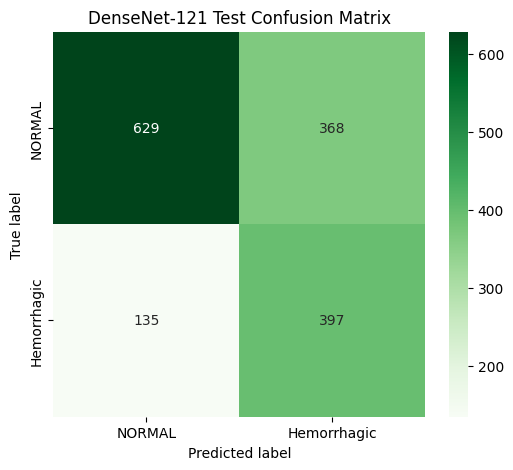

In [22]:
confusion_matrix_values = confusion_matrix(
    test_labels,
    test_predictions,
    labels=[0, 1],
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix_values,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names,
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("DenseNet-121 Test Confusion Matrix")
plt.show()

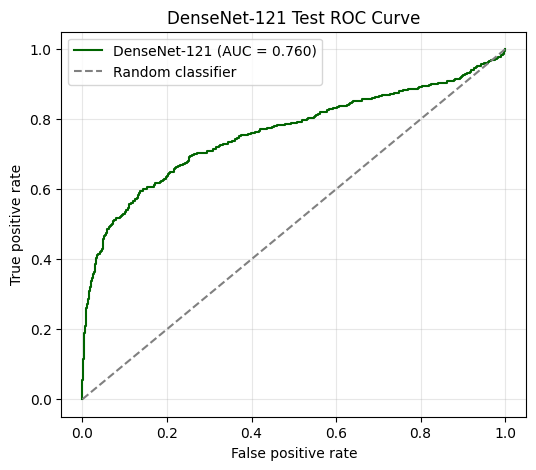

In [23]:
from sklearn.metrics import roc_curve

false_positive_rate, true_positive_rate, _ = roc_curve(
    test_labels,
    test_probabilities,
)

plt.figure(figsize=(6, 5))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    color="darkgreen",
    label=f"DenseNet-121 (AUC = {test_auc:.3f})",
)

plt.plot([0, 1], [0, 1], "--", color="gray", label="Random classifier")

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("DenseNet-121 Test ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

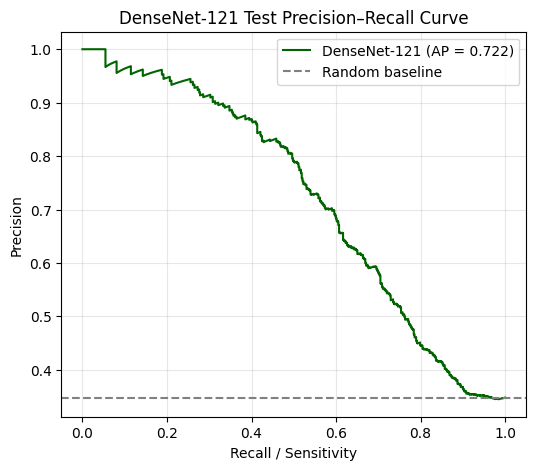

In [24]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, _ = precision_recall_curve(
    test_labels,
    test_probabilities,
)

plt.figure(figsize=(6, 5))

plt.plot(
    recall_curve,
    precision_curve,
    color="darkgreen",
    label=f"DenseNet-121 (AP = {test_metrics['PR-AUC']:.3f})",
)

plt.axhline(
    test_labels.mean(),
    linestyle="--",
    color="gray",
    label="Random baseline",
)

plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision")
plt.title("DenseNet-121 Test Precision–Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

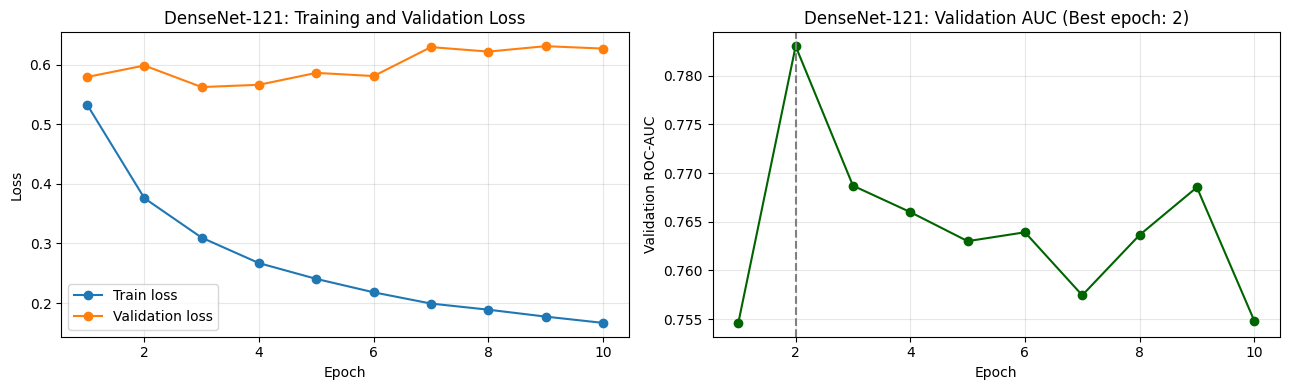

In [25]:
epochs = range(1, len(history["train_loss"]) + 1)
best_epoch = np.argmax(history["val_auc"]) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs, history["train_loss"], marker="o", label="Train loss")
axes[0].plot(epochs, history["val_loss"], marker="o", label="Validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("DenseNet-121: Training and Validation Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["val_auc"], marker="o", color="darkgreen")
axes[1].axvline(best_epoch, linestyle="--", color="gray")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation ROC-AUC")
axes[1].set_title(f"DenseNet-121: Validation AUC (Best epoch: {best_epoch})")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()